In [9]:
import cpi
import pandas as pd
import numpy as np
from datetime import date
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from pmdarima.arima import ndiffs, nsdiffs
from stationarityTestUtils import test_autocorrelation

### 데이터 불러오기(금시세 2000~2011년도)

In [10]:
# Yahoo Finance에서 수집한 CSV
file_path = "../Data-collection/dailyStock"
target = "GC=F"
file_path = f"{file_path}/{target}.csv"
df = pd.read_csv(file_path, encoding="utf-8")


df['Date'] = pd.to_datetime(df['Date']) # 날짜로 변환
df = df.set_index('Date')               # Date를 인덱스로 설정
df = df.loc['2000-01-01':'2011-12-31']  # 분석 기간
df = df['Close'].resample('ME').mean()  # 월평균 가격 계산
df = df.to_frame(name='price')          # 컬럼명 변경

df.index = df.index.to_period('M')      #인덱스 형식 변경(yyyy-mm-dd -> yyyy-mm)

df.head()

,price
Date,
2000-08,276.099991
2000-09,273.389996
2000-10,269.809090
2000-11,265.874997
2000-12,271.515005


### 인플레이션 정보 불러오기

In [11]:
series = cpi.series.get()

cpi_df = series.to_dataframe()
cpi_df['Date'] = pd.to_datetime(cpi_df['date'])
cpi_df = cpi_df.rename(columns={'value': 'cpi'})
cpi_df = cpi_df[['Date', 'cpi']].set_index('Date')

cpi_df.index = cpi_df.index.to_period('M')      #인덱스 형식 변경(yyyy-mm-dd -> yyyy-mm)
cpi_df.head()

,cpi
Date,
1997-01,159.1
1997-02,159.6
1997-03,160.0
1997-04,160.2
1997-05,160.1


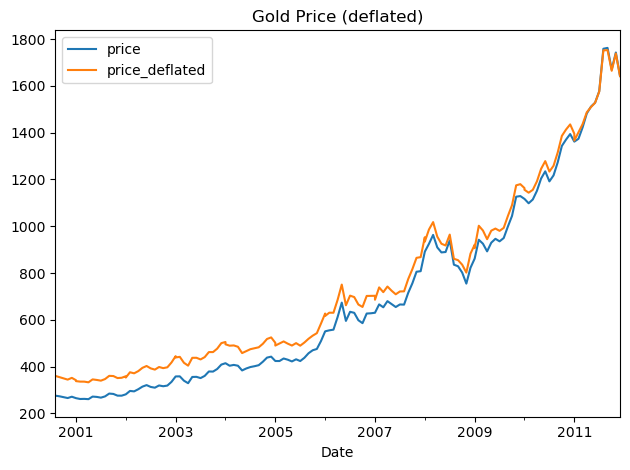

In [12]:
#기준 cpi 설정
DEFL_DATE = pd.Timestamp('2011-12-31').to_period('M')
target_cpi = cpi_df.loc[DEFL_DATE, "cpi"]

#월별 금가격에 CPI Join
df = df.join(cpi_df)

## 인플레이션 보정 가격 계산
df['price_deflated'] = (df['price'] * target_cpi / df['cpi'])

df[['price', 'price_deflated']].plot(title='Gold Price (deflated)')

plt.tight_layout()
plt.show()

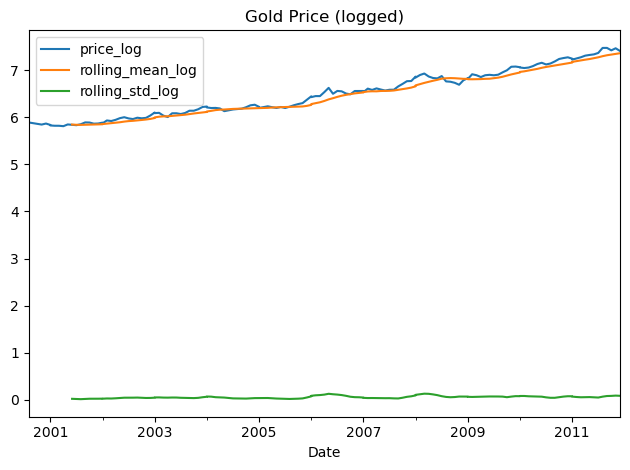

In [13]:
WINDOW = 12
selected_columns = ['price_log', 'rolling_mean_log', 'rolling_std_log']

df['price_log'] = np.log(df.price_deflated)
df['rolling_mean_log'] = df.price_log.rolling(WINDOW).mean()
df['rolling_std_log'] = df.price_log.rolling(WINDOW).std()

df[selected_columns].plot(title='Gold Price (logged)')

plt.tight_layout()
plt.show()

### 원본데이터 정상성 검정

C:\Users\ckddn\workspace\financial-analysis\time_series_modeling\stationarityTestUtils.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(x, regression=h0_type)


ADF 검정통계량: 0.55 (p-value: 0.99) -> 검정결과:비정상성 데이터
KPSS 검정통계량: 1.72 (p-value: 0.01) -> 검정결과:비정상성 데이터


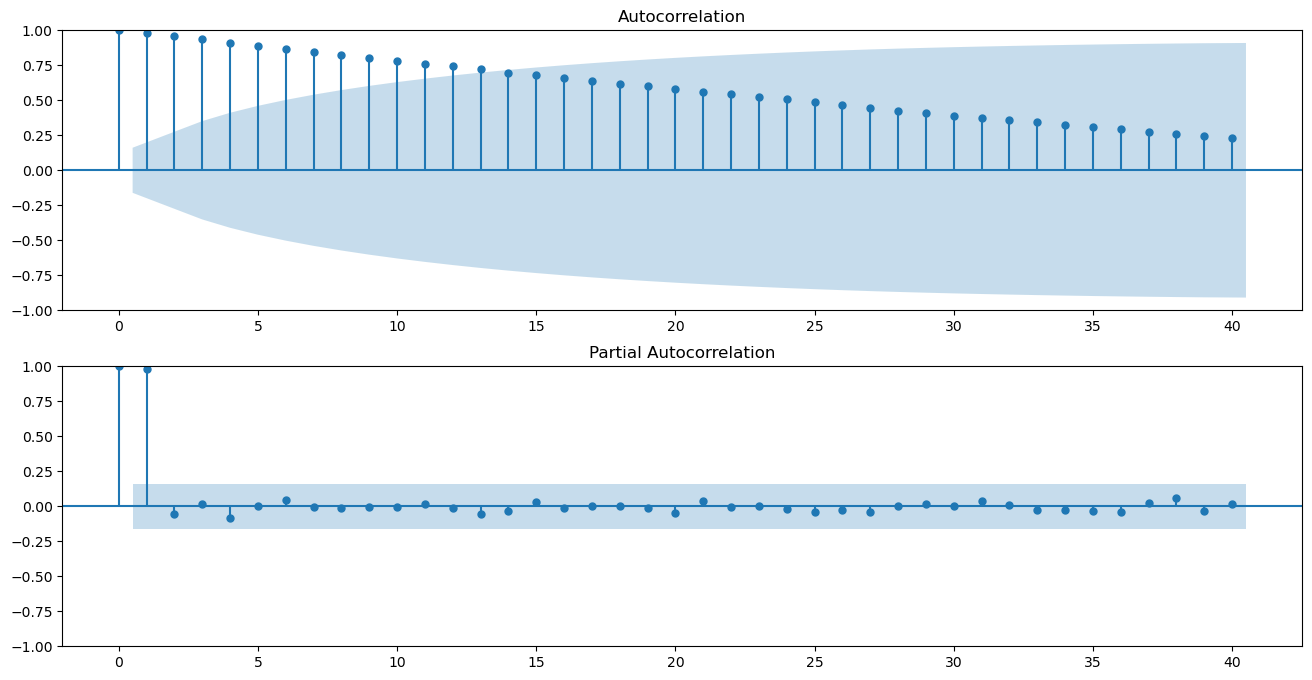

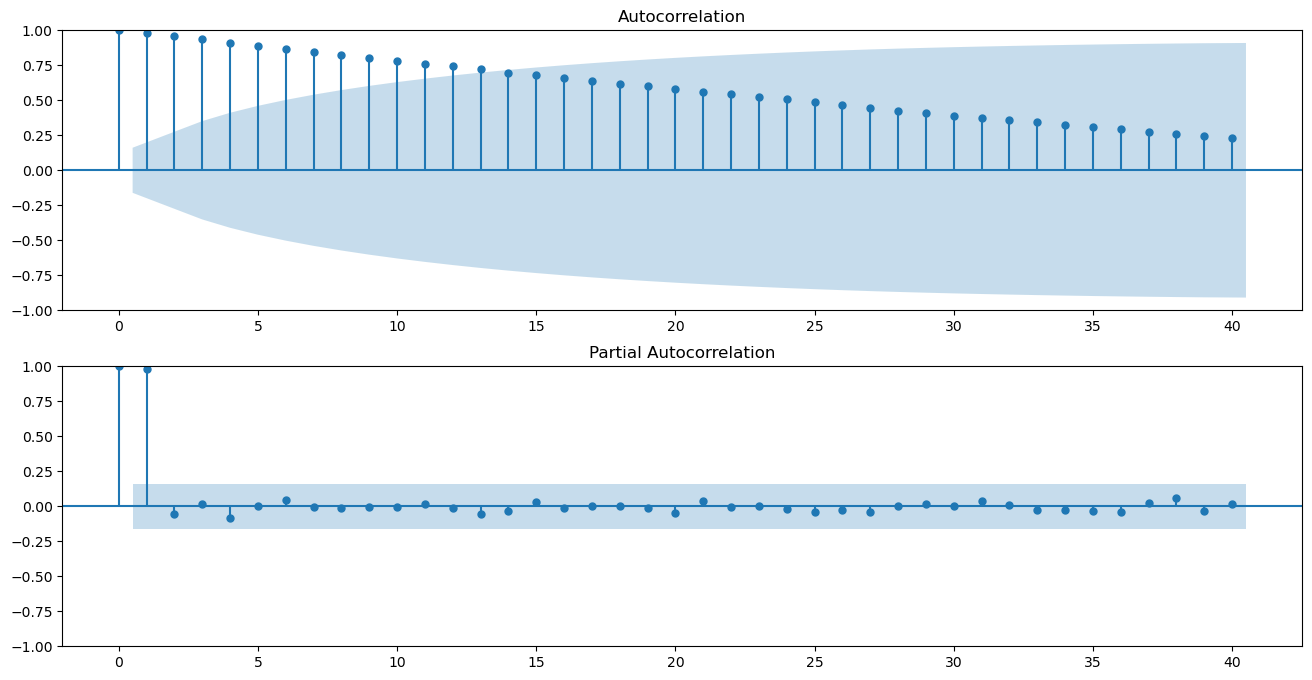

In [14]:
test_autocorrelation(df.price_log)

### 차분횟수추정

In [27]:
print(f"차분횟수추정 (ADF): {ndiffs(df.price, test='adf')}")
print(f"차분횟수추정 (KPSS): {ndiffs(df.price, test='kpss')}")
print(f"차분횟수추정 (PP): {ndiffs(df.price, test='pp')}")
print(f"계절성차분횟수추정 (OSCB): {nsdiffs(df.price, m=12, test='ocsb')}")
print(f"계절성차분횟수추정 (CH): {nsdiffs(df.price, m=12, test='ch')}")

차분횟수추정 (ADF): 1
차분횟수추정 (KPSS): 2
차분횟수추정 (PP): 1
계절성차분횟수추정 (OSCB): 0
계절성차분횟수추정 (CH): 0


### 차분적용

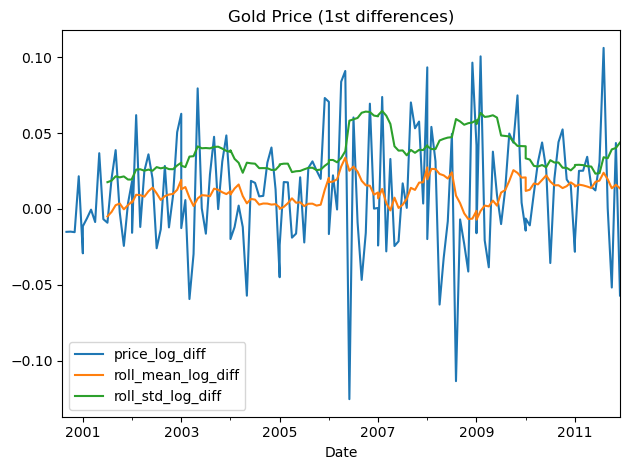

In [9]:
selected_columns = ['price_log_diff', 'roll_mean_log_diff', 'roll_std_log_diff']

df['price_log_diff'] = df.price_log.diff(1)
df['roll_mean_log_diff'] = df.price_log_diff.rolling(WINDOW).mean()
df['roll_std_log_diff'] = df.price_log_diff.rolling(WINDOW).std()
df[selected_columns].plot(title='Gold Price (1st differences)')

plt.tight_layout()
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_2492\105167561.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(x, regression=h0_type)


ADF 검정통계량: -12.59 (p-value: 0.00) -> 검정결과:정상성 데이터
KPSS 검정통계량: 0.16 (p-value: 0.10) -> 검정결과:정상성 데이터


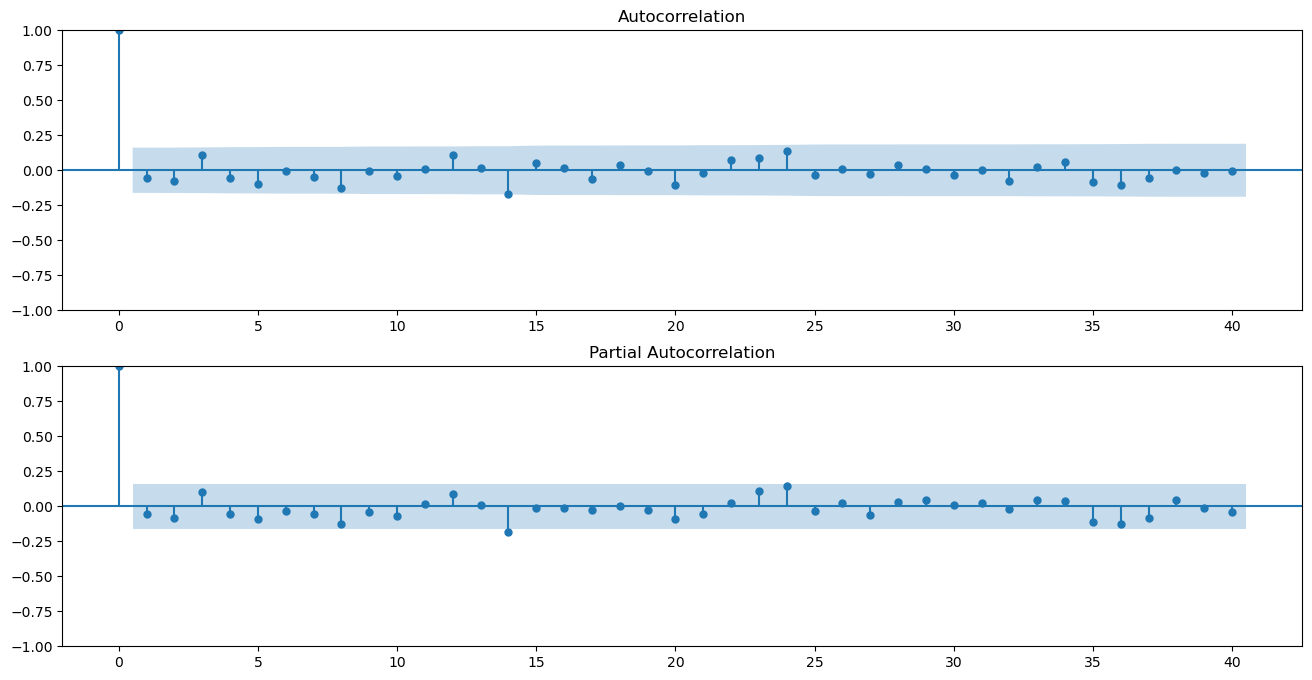

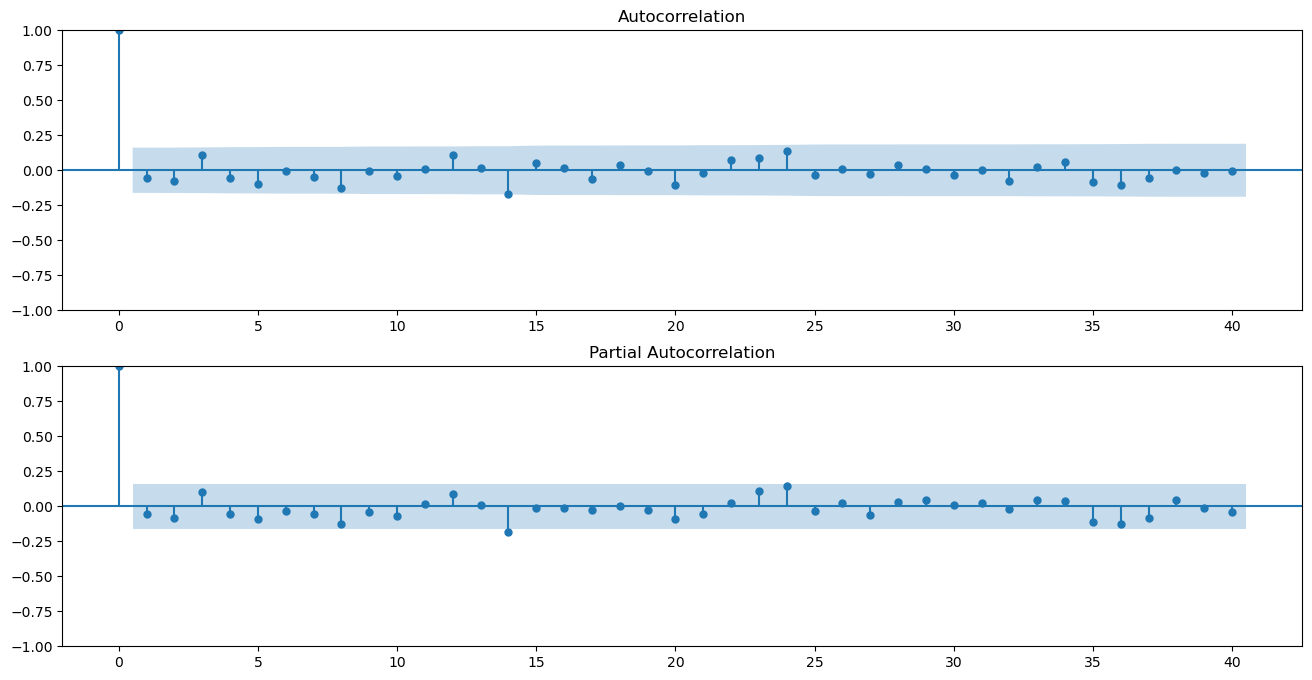

In [26]:
test_autocorrelation(df.price_log_diff.dropna())